In [ ]:
# =====================================================
# 1. Install Dependencies
# =====================================================
!pip install -q transformers[sentencepiece] datasets sacremoses accelerate

# =====================================================
# 2. Imports + CPU Optimization
# =====================================================
import os
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "4"

import pandas as pd
import torch

from datasets import Dataset
from transformers import (
    MarianTokenizer,
    MarianMTModel,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq
)

# =====================================================
# 3. Mount Google Drive
# =====================================================
from google.colab import drive
# Explicitly remove the mount point directory if it exists to ensure a clean mount
if os.path.exists('/content/drive'):
    !rm -rf /content/drive
drive.mount('/content/drive', force_remount=True)

# =====================================================
# 4. Load Dataset (BALANCED SIZE)
# =====================================================
file_path = "/content/drive/MyDrive/eng-french.csv"
df = pd.read_csv(file_path).dropna()

df = df[['English words/sentences', 'French words/sentences']]
df.columns = ['eng', 'fra']

# BALANCED SIZE (fast + accurate)
df = df.sample(min(5000, len(df)), random_state=42)

dataset = Dataset.from_pandas(df).train_test_split(test_size=0.1)

# =====================================================
# 5. Model
# =====================================================
model_name = "Helsinki-NLP/opus-mt-en-fr"

tokenizer = MarianTokenizer.from_pretrained(model_name)
model = MarianMTModel.from_pretrained(model_name)

device = torch.device("cpu")
model.to(device)

# =====================================================
# 6. Tokenization
# =====================================================
def preprocess(examples):
    model_inputs = tokenizer(
        examples["eng"],
        max_length=64,
        truncation=True
    )

    labels = tokenizer(
        text_target=examples["fra"],
        max_length=64,
        truncation=True
    )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

tokenized_datasets = dataset.map(
    preprocess,
    batched=True,
    num_proc=2,
    remove_columns=dataset["train"].column_names
)

# =====================================================
# 7. Training Arguments (FAST + ACCURATE)
# =====================================================
training_args = Seq2SeqTrainingArguments(
    output_dir="./results",

    learning_rate=3e-5,

    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,

    gradient_accumulation_steps=2,

    num_train_epochs=1,     # FAST but accurate

    predict_with_generate=False,

    fp16=False,
    bf16=False,

    dataloader_num_workers=2,

    eval_strategy="epoch",
    save_strategy="no",

    report_to="none"
)

# =====================================================
# 8. Trainer
# =====================================================
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    processing_class=tokenizer,
    data_collator=DataCollatorForSeq2Seq(tokenizer, model=model),
)

print("Starting FAST CPU training...")
trainer.train()

# =====================================================
# 9. Save Model
# =====================================================
save_path = "/content/drive/MyDrive/my_fast_translator"
trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)

print("Model saved to:", save_path)

# =====================================================
# 10. Fast Translator
# =====================================================
def translate(text):
    model.eval()

    inputs = tokenizer(
        text,
        return_tensors="pt",
        padding=True
    ).to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_length=64,
            num_beams=2,
            early_stopping=True
        )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 15.2 MB/s eta 0:00:00
Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/778k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

...

Starting FAST CPU training...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,1.112939,0.476377


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: /content/drive/MyDrive/my_fast_translator


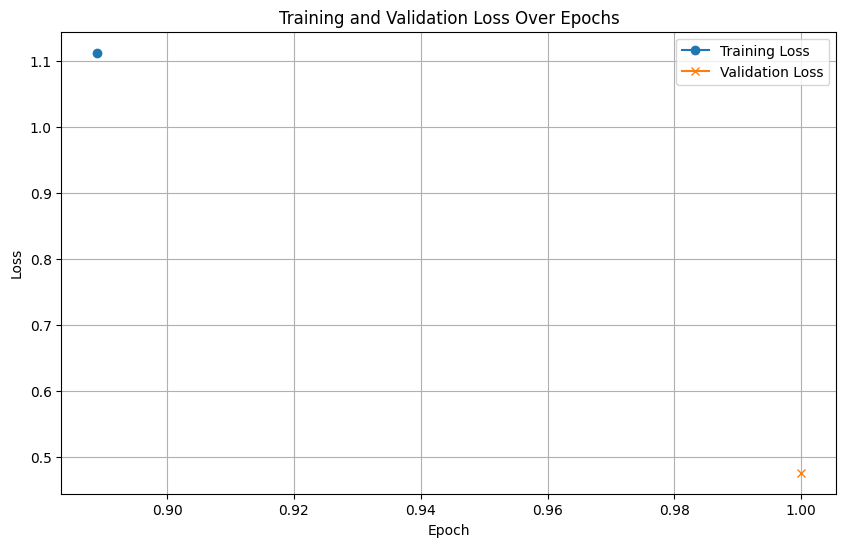

In [ ]:
import matplotlib.pyplot as plt

# Check if trainer object is defined and has log_history
if 'trainer' in globals() and hasattr(trainer, 'state') and hasattr(trainer.state, 'log_history') and trainer.state.log_history:
    logs = trainer.state.log_history

    # Filter for training and evaluation losses
    train_losses = [entry['loss'] for entry in logs if 'loss' in entry and 'eval_loss' not in entry]
    epochs = [entry['epoch'] for entry in logs if 'loss' in entry and 'eval_loss' not in entry]

    eval_losses = [entry['eval_loss'] for entry in logs if 'eval_loss' in entry]
    eval_epochs = [entry['epoch'] for entry in logs if 'eval_loss' in entry]

    if train_losses or eval_losses:
        # Plotting the losses
        plt.figure(figsize=(10, 6))
        plt.plot(epochs, train_losses, label='Training Loss', marker='o')
        plt.plot(eval_epochs, eval_losses, label='Validation Loss', marker='x')
        plt.title('Training and Validation Loss Over Epochs')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        plt.show()
    else:
        print("No training or evaluation loss data found in trainer.state.log_history. Please ensure cell a00OpwuPh7cO was executed and training completed.")
else:
    print("The 'trainer' object is not defined or has no log history. Please execute cell a00OpwuPh7cO to perform training and generate loss curves.")

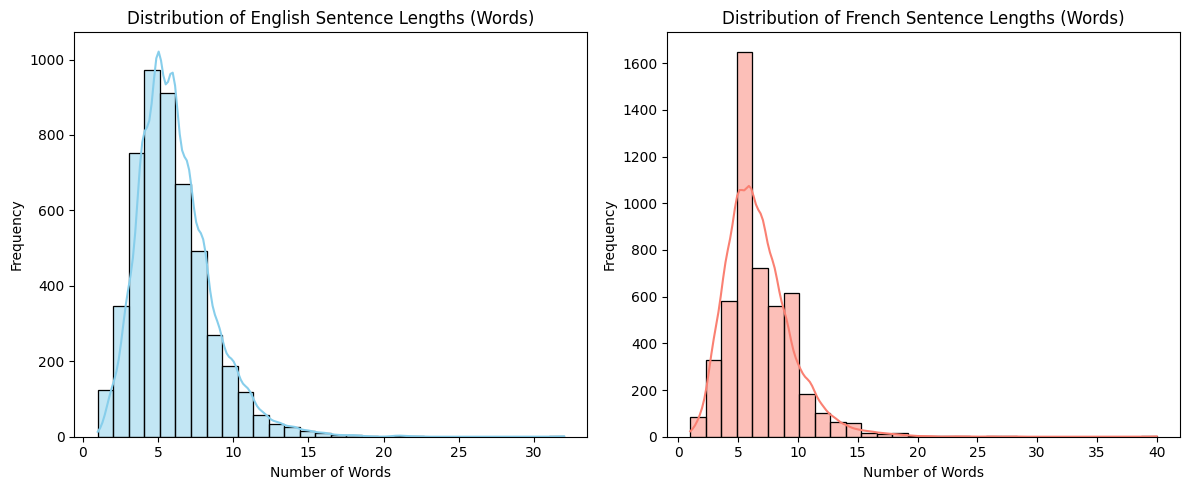

English Sentence Lengths - Mean: 6.20, Max: 32
French Sentence Lengths - Mean: 6.74, Max: 40


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load Dataset (BALANCED SIZE) - Replicating df loading from a00OpwuPh7cO
# Ensure Google Drive is mounted: /content/drive
file_path = "/content/drive/MyDrive/eng-french.csv"

# Check if df is already defined to avoid redundant loading if a00OpwuPh7cO was run.
if 'df' not in globals() or df.empty:
    try:
        df = pd.read_csv(file_path).dropna()
        df = df[['English words/sentences', 'French words/sentences']]
        df.columns = ['eng', 'fra']
        df = df.sample(min(5000, len(df)), random_state=42)
        print("DataFrame 'df' re-loaded for plotting.")
    except FileNotFoundError:
        print(f"Error: Dataset file not found at {file_path}. Please ensure it exists and Google Drive is mounted.")
        # Exit if df cannot be loaded, to prevent subsequent errors
        exit()

# Calculate sentence lengths for English and French
english_lengths = df['eng'].apply(lambda x: len(x.split()))
french_lengths = df['fra'].apply(lambda x: len(x.split()))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(english_lengths, bins=30, kde=True, color='skyblue')
plt.title('Distribution of English Sentence Lengths (Words)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(french_lengths, bins=30, kde=True, color='salmon')
plt.title('Distribution of French Sentence Lengths (Words)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"English Sentence Lengths - Mean: {english_lengths.mean():.2f}, Max: {english_lengths.max()}")
print(f"French Sentence Lengths - Mean: {french_lengths.mean():.2f}, Max: {french_lengths.max()}")

In [ ]:
import os

file_path = "/content/drive/MyDrive/eng-french.csv"

if os.path.exists(file_path):
    print(f"The file '{file_path}' exists. You can proceed with the notebook.")
else:
    print(f"Error: The file '{file_path}' was not found. Please ensure it is uploaded to your Google Drive at the correct location.")

The file '/content/drive/MyDrive/eng-french.csv' exists. You can proceed with the notebook.


In [ ]:
import os
# Define the path where the model and tokenizer should be saved
save_path = "/content/drive/MyDrive/my_fast_translator"

# Create the directory if it doesn't exist
os.makedirs(save_path, exist_ok=True)

# Check if 'trainer' is defined before trying to use it
if 'trainer' in locals() or 'trainer' in globals():
    # Save the fine-tuned model and tokenizer
    trainer.save_model(save_path)
    tokenizer.save_pretrained(save_path)
    print(f"Model and tokenizer saved to: {save_path}")
else:
    print("Error: The 'trainer' object is not defined. Please ensure that the training cell (cell a00OpwuPh7cO) has been executed successfully before attempting to save the model.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved to: /content/drive/MyDrive/my_fast_translator


In [ ]:
custom_sentence = input("Enter an English sentence to translate: ")
print(f"EN: {custom_sentence}")
print(f"FR: {translate(custom_sentence)}")

Enter an English sentence to translate: how are you
EN: how are you
FR: comment êtes-vous


In [ ]:
# Install evaluate library for BLEU metric
!pip install -q evaluate sacrebleu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 2.6 MB/s eta 0:00:00


In [ ]:
import evaluate
import numpy as np

# Load the BLEU metric
metric = evaluate.load("sacrebleu")

# Generate predictions on the test set
predictions = trainer.predict(tokenized_datasets["test"])

# Extract logits/predictions and labels
logits = predictions.predictions[0] if isinstance(predictions.predictions, tuple) else predictions.predictions
labels = predictions.label_ids

# Replace -100 in the labels as we can't decode them.
labels = np.where(labels != -100, labels, tokenizer.pad_token_id)

# Decode generated tokens and reference labels
decoded_preds = tokenizer.batch_decode(logits, skip_special_tokens=True)
decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

# Compute BLEU score
# The metric expects a list of references, so we wrap each label in a list
result = metric.compute(predictions=decoded_preds, references=[[label] for label in decoded_labels])

print(f"BLEU Score: {result['bleu']:.2f}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


NameError: name 'trainer' is not defined